In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))


path = '/Volumes/Elements/PTM_project/FLNC24/pS2718trans_METAD/DATA_PLUMED/'

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:29: RuntimeWarning: divide by zero encountered in log


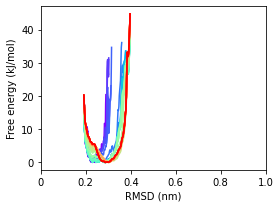

In [2]:
# time course convergence
T=298
sim=1

times = np.arange(220,1020,20)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

data = np.loadtxt(path+'COLVAR.{}'.format(sim))
rbias = data[:,3]

CV = np.loadtxt(path+'../RMSD_SASA_data/rmsd_BB{}.xvg'.format(sim),skiprows=18)[:,1]

plt.figure(figsize = (4,3))


for t,c in zip(times,colors):
    
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    plt.plot(x[:-1],fel,color = c)
    
# formatting

plt.xlabel('RMSD (nm)')
plt.xlim(0,1)
plt.xticks(ticks=[0,0.2,0.4,0.6,0.8,1.0],labels=[0,0.2,0.4,0.6,0.8,1.0])
plt.ylabel('Free energy (kJ/mol)')
#plt.ylim(0,20)


plt.tight_layout()
plt.savefig('rbias_rmsd_FEL_timecourse_sim{}.png'.format(sim))

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:29: RuntimeWarning: divide by zero encountered in log
/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/numpy/core/_methods.py:193: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


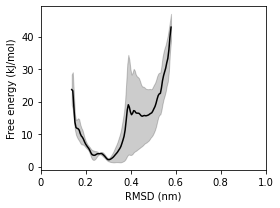

In [4]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(s))
    CV = np.loadtxt(path+'../RMSD_SASA_data/rmsd_BB{}.xvg'.format(s),skiprows=18)[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('RMSD (nm)')
plt.xlim(0,1)
plt.xticks(ticks=[0,0.2,0.4,0.6,0.8,1.0],labels=[0,0.2,0.4,0.6,0.8,1.0])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_RMSD.png')

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:36: RuntimeWarning: divide by zero encountered in log


<Figure size 288x216 with 0 Axes>

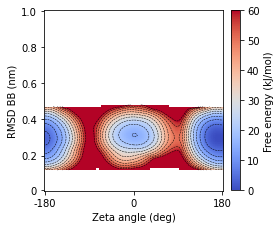

In [6]:
# convergence with rbias reweighting BF15

T = 298
sim=1

t= 1000
t_discard = 200


data = np.loadtxt(path+'COLVAR.{}'.format(sim))
zeta = data[:,1]
RMSD = np.loadtxt(path+'../RMSD_SASA_data/rmsd_BB{}.xvg'.format(sim),skiprows=18)[:,1]
rbias = data[:,3]

xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
yedges = np.arange(0,1.01,0.01)

frame = int(t*1000/5)
init_frame = int(t_discard*1000/5)
    
# FEL rbias reweighting
kbt = 0.008314*T

plt.figure(figsize = (4,3))


weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
weights = weights/np.sum(weights)

x=zeta[init_frame:frame]
y=RMSD[init_frame:frame]

H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H) # convert counts to probility
h = -kbt*np.log(h) # calculate free energy from probability
h = h-np.min(h) # set minimum to 0 kbT
h = h.T


max_energy = 60
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='coolwarm')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-180','0','180']
ylabels = [0,0.2,0.4,0.6,0.8,1.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))

plt.xlabel('Zeta angle (deg)')
plt.ylabel('RMSD BB (nm)')

plt.tight_layout()
plt.savefig('2D_zeta_vs_RMSD_FEL_sim{}.png'.format(sim))

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:36: RuntimeWarning: divide by zero encountered in log


<Figure size 288x216 with 0 Axes>

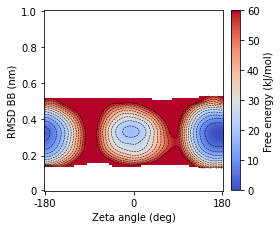

In [7]:
# convergence with rbias reweighting BF15

T = 298
sim=2

t= 1000
t_discard = 200


data = np.loadtxt(path+'COLVAR.{}'.format(sim))
zeta = data[:,1]
RMSD = np.loadtxt(path+'../RMSD_SASA_data/rmsd_BB{}.xvg'.format(sim),skiprows=18)[:,1]
rbias = data[:,3]

xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
yedges = np.arange(0,1.01,0.01)

frame = int(t*1000/5)
init_frame = int(t_discard*1000/5)
    
# FEL rbias reweighting
kbt = 0.008314*T

plt.figure(figsize = (4,3))


weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
weights = weights/np.sum(weights)

x=zeta[init_frame:frame]
y=RMSD[init_frame:frame]

H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H) # convert counts to probility
h = -kbt*np.log(h) # calculate free energy from probability
h = h-np.min(h) # set minimum to 0 kbT
h = h.T


max_energy = 60
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='coolwarm')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-180','0','180']
ylabels = [0,0.2,0.4,0.6,0.8,1.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))

plt.xlabel('Zeta angle (deg)')
plt.ylabel('RMSD BB (nm)')

plt.tight_layout()
plt.savefig('2D_zeta_vs_RMSD_FEL_sim{}.png'.format(sim))

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:36: RuntimeWarning: divide by zero encountered in log


<Figure size 288x216 with 0 Axes>

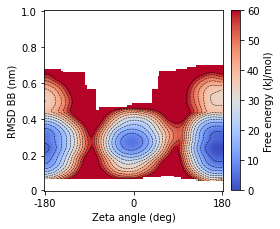

In [8]:
# convergence with rbias reweighting BF15

T = 298
sim=3

t= 1000
t_discard = 200


data = np.loadtxt(path+'COLVAR.{}'.format(sim))
zeta = data[:,1]
RMSD = np.loadtxt(path+'../RMSD_SASA_data/rmsd_BB{}.xvg'.format(sim),skiprows=18)[:,1]
rbias = data[:,3]

xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
yedges = np.arange(0,1.01,0.01)

frame = int(t*1000/5)
init_frame = int(t_discard*1000/5)
    
# FEL rbias reweighting
kbt = 0.008314*T

plt.figure(figsize = (4,3))


weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
weights = weights/np.sum(weights)

x=zeta[init_frame:frame]
y=RMSD[init_frame:frame]

H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H) # convert counts to probility
h = -kbt*np.log(h) # calculate free energy from probability
h = h-np.min(h) # set minimum to 0 kbT
h = h.T


max_energy = 60
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='coolwarm')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-180','0','180']
ylabels = [0,0.2,0.4,0.6,0.8,1.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))

plt.xlabel('Zeta angle (deg)')
plt.ylabel('RMSD BB (nm)')

plt.tight_layout()
plt.savefig('2D_zeta_vs_RMSD_FEL_sim{}.png'.format(sim))